# CRF iter sweep

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

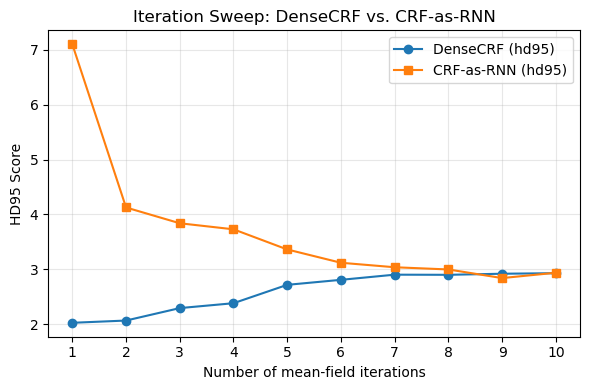

In [8]:
import json
import matplotlib.pyplot as plt

# ---- Paths to your JSON files ----
dense_json_path = "outputs_crf_iter_sweep/sweep_iter_dense_fix.json"
crfrnn_json_path = "outputs_crf_iter_sweep/sweep_iter_crfrnn_fix.json"

# ---- Helper: load 'dice' metric per iteration ----
def load_metric_per_iter(json_path, metric="dice"):
    with open(json_path, "r") as f:
        data = json.load(f)

    # Keys in the JSON are likely strings "1", "2", ..., "10"
    iters = sorted(data.keys(), key=lambda x: int(x))
    xs = [int(k) for k in iters]
    ys = [data[k][metric] for k in iters]
    return xs, ys

# Load Dice curves
iters_dense, dice_dense = load_metric_per_iter(dense_json_path, metric="hd95")
iters_crf,   dice_crf   = load_metric_per_iter(crfrnn_json_path, metric="hd95")

# ---- Plot ----
plt.figure(figsize=(6, 4))

plt.plot(iters_dense, dice_dense, marker="o", label="DenseCRF (hd95)")
plt.plot(iters_crf,   dice_crf,   marker="s", label="CRF-as-RNN (hd95)")

plt.xlabel("Number of mean-field iterations")
plt.ylabel("HD95 Score")
plt.title("Iteration Sweep: DenseCRF vs. CRF-as-RNN")
plt.xticks(range(1, 11))  # 1..10
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Optional: save to file
plt.savefig("iter_sweep_hd95_comparison.png", dpi=200)

plt.show()


# Dense CRF grid

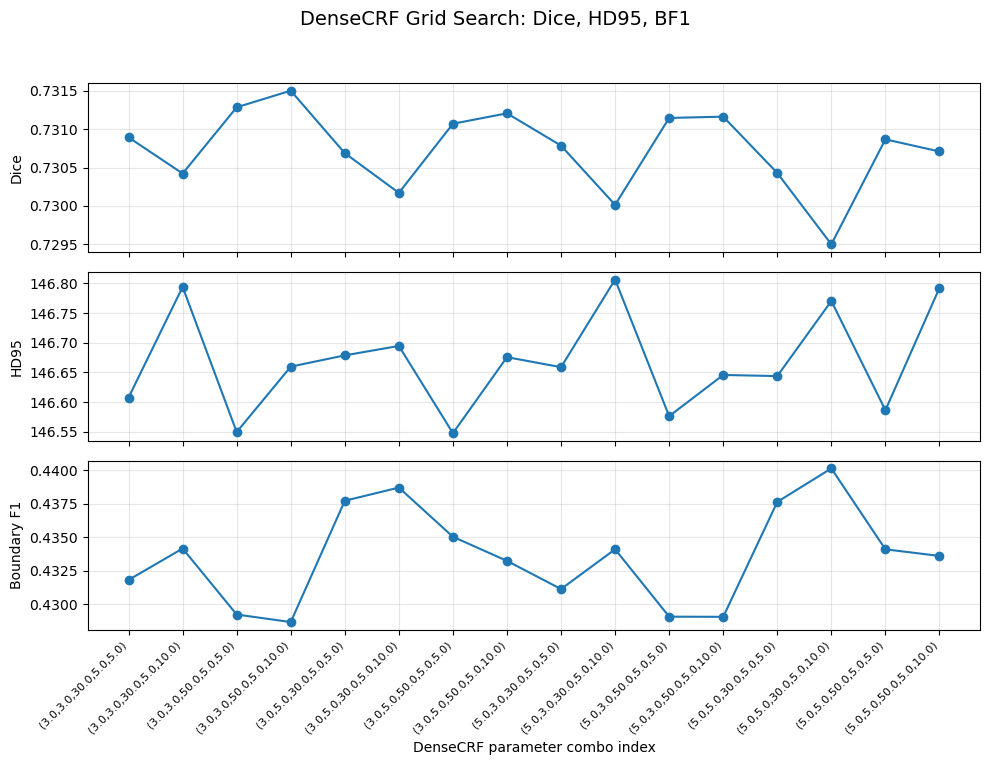

In [9]:
import json
import ast
import matplotlib.pyplot as plt

# Path to your grid results
GRID_JSON_PATH = "outputs_densecrf_grid/densecrf_grid_results.json"

def load_grid_results(path):
    with open(path, "r") as f:
        data = json.load(f)

    # Keys are strings like "(3.0, 3.0, 30.0, 5.0, 5.0)"
    # Parse them into tuples so we can sort consistently
    records = []
    for k, v in data.items():
        params = ast.literal_eval(k)  # (sxy_gauss, compat_gauss, sxy_bi, srgb_bi, compat_bi)
        records.append((params, v))

    # Sort by params for stable ordering
    records.sort(key=lambda x: x[0])
    return records

def main():
    records = load_grid_results(GRID_JSON_PATH)

    # X-axis: just index of the combination
    xs = list(range(len(records)))

    # Metrics
    dice_vals = []
    hd95_vals = []
    bf1_vals = []
    labels = []  # short string labels for x-ticks

    for params, metrics in records:
        dice_vals.append(metrics["dice"])
        hd95_vals.append(metrics["hd95"])
        bf1_vals.append(metrics["bf1"])
        # make a short label, e.g. "(3,3,30,5,5)"
        labels.append("(" + ",".join(str(p) for p in params) + ")")

    # ---- Plotting ----
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # 1) Dice
    axes[0].plot(xs, dice_vals, marker="o")
    axes[0].set_ylabel("Dice")
    axes[0].grid(True, alpha=0.3)

    # 2) HD95
    axes[1].plot(xs, hd95_vals, marker="o")
    axes[1].set_ylabel("HD95")
    axes[1].grid(True, alpha=0.3)

    # 3) BF1
    axes[2].plot(xs, bf1_vals, marker="o")
    axes[2].set_ylabel("Boundary F1")
    axes[2].set_xlabel("DenseCRF parameter combo index")
    axes[2].grid(True, alpha=0.3)

    # Optional: show the actual parameter tuples on the x-axis
    axes[2].set_xticks(xs)
    axes[2].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

    fig.suptitle("DenseCRF Grid Search: Dice, HD95, BF1", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save figure
    plt.savefig("densecrf_grid_metrics.png", dpi=200)
    plt.show()

if __name__ == "__main__":
    main()
